In [29]:
import pandas as pd
import numpy as np



### Data Understanding

In [30]:
df= pd.read_csv('Amazon.csv')
df.head()


,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


In [31]:
df.shape

(100000, 20)

In [32]:
df.columns

Index(['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID',
       'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice', 'Discount',
       'Tax', 'ShippingCost', 'TotalAmount', 'PaymentMethod', 'OrderStatus',
       'City', 'State', 'Country', 'SellerID'],
      dtype='object')

In [33]:
df.describe()

,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,3.001400,302.905748,0.074226,68.468902,7.406660,918.256479
std,1.413548,171.840797,0.082583,74.131180,4.324057,724.508332
min,1.000000,5.000000,0.000000,0.000000,0.000000,4.270000
25%,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000
50%,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000
75%,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000
max,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000


In [34]:
df.dtypes

OrderID           object
OrderDate         object
CustomerID        object
CustomerName      object
ProductID         object
ProductName       object
Category          object
Brand             object
Quantity           int64
UnitPrice        float64
Discount         float64
Tax              float64
ShippingCost     float64
TotalAmount      float64
PaymentMethod     object
OrderStatus       object
City              object
State             object
Country           object
SellerID          object
dtype: object

### Data Preparation - Data Cleaning

In [35]:
# Order date is currently an object, we need to convert it to datetime format for easier analysis.

df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['MonthYear'] = df['OrderDate'].dt.to_period('M') # Creating a monthly cohort

In [36]:
df['MonthYear'].head()

0    2023-01
1    2023-12
2    2022-05
3    2023-07
4    2023-02
Name: MonthYear, dtype: period[M]

### Data Manipulation

In [37]:
# Calculate key metrics

print("Total Revenue:", df['TotalAmount'].sum())
print("Average Order Value:", df['TotalAmount'].mean())
print("Cancellation Rate:", (df['OrderStatus'] == 'Cancelled').mean() * 100)

Total Revenue: 91825647.92
Average Order Value: 918.2564792000001
Cancellation Rate: 3.028


In [38]:
# Analyse performance by category, country, and payment method.

category_perf = df.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False)
country_perf = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False)
payment_method_perf = df.groupby('PaymentMethod')['TotalAmount'].sum().sort_values(ascending=False)
shipping_cost_by_category = df.groupby('Category')['ShippingCost'].sum().sort_values(ascending=False)
print("Revenue by Category:\n", category_perf)
print("\nRevenue by Country:\n", country_perf)
print("\nRevenue by Payment Method:\n", payment_method_perf)
print("\nShipping Cost by Category:\n", shipping_cost_by_category)

Revenue by Category:
 Category
Electronics          15584217.18
Sports & Outdoors    15345571.88
Books                15261837.01
Clothing             15253397.50
Toys & Games         15216684.99
Home & Kitchen       15163939.36
Name: TotalAmount, dtype: float64

Revenue by Country:
 Country
United States     64310048.50
India             13875839.12
Canada             5323757.00
United Kingdom     4526896.86
Australia          3789106.44
Name: TotalAmount, dtype: float64

Revenue by Payment Method:
 PaymentMethod
Credit Card         32122158.69
Debit Card          18538678.53
UPI                 13896028.55
Amazon Pay          13697498.42
Net Banking          9055674.57
Cash on Delivery     4515609.16
Name: TotalAmount, dtype: float64

Shipping Cost by Category:
 Category
Electronics          125399.94
Sports & Outdoors    124523.57
Books                123604.49
Home & Kitchen       122880.71
Toys & Games         122719.08
Clothing             121538.22
Name: ShippingCost, dtype: flo

### Data Visualisation

In [39]:
pip install squarify

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import squarify

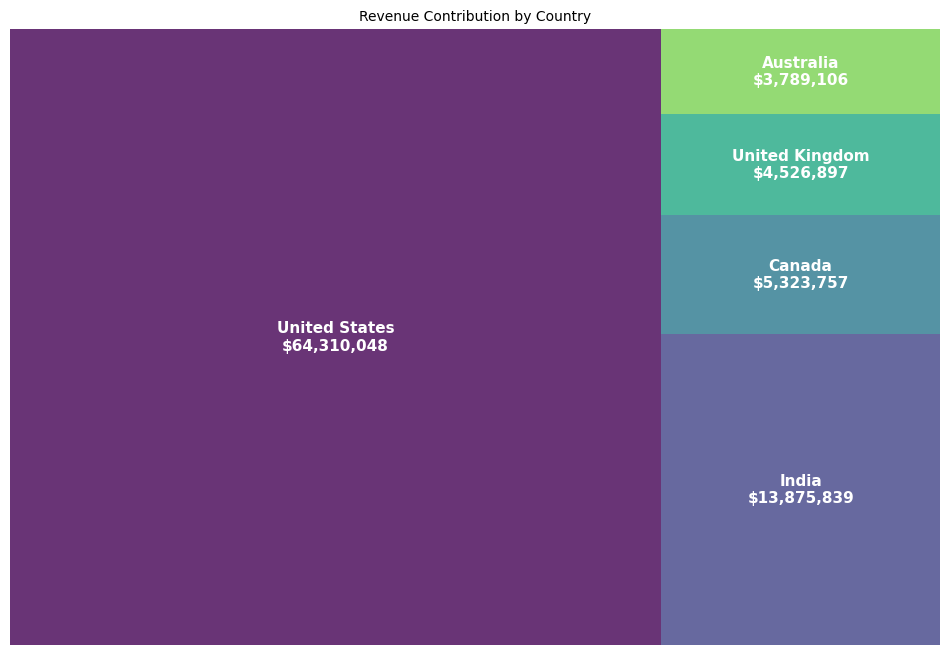

In [41]:
# 1. Prepare the data
country_sales = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).reset_index()

# 2. Define labels with revenue (to show inside the blocks)
labels = [f"{row['Country']}\n${row['TotalAmount']:,.0f}" for _, row in country_sales.iterrows()]
sizes = country_sales['TotalAmount'].values

plt.figure(figsize=(12, 8))
colors = plt.cm.viridis([i/float(len(labels)) for i in range(len(labels))]) # Using 'viridis' palette

squarify.plot(sizes=sizes, label=labels, color=colors, alpha=0.8, 
              text_kwargs={'color': 'white', 'weight': 'bold', 'fontsize': 11})

plt.title('Revenue Contribution by Country', fontsize=10)
plt.axis('off') # Treemaps don't need axes
plt.show()

C:\Users\Dan\AppData\Local\Temp\ipykernel_11964\3937253239.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1, 1], x=brand_sales.values, y=brand_sales.index, palette='magma')


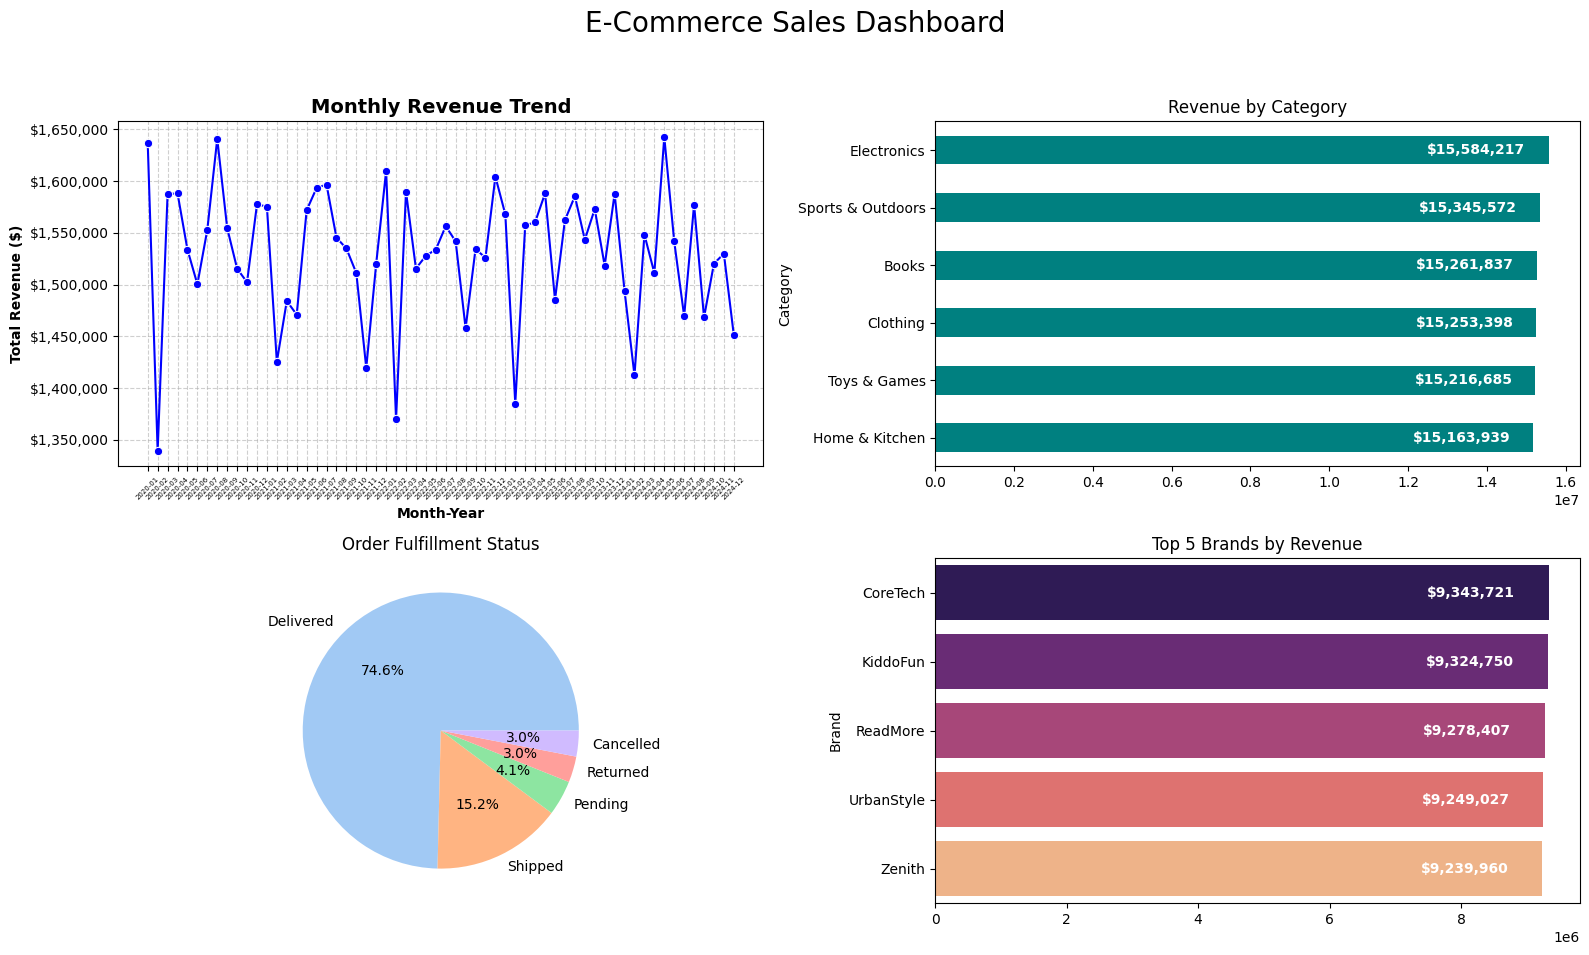

In [44]:
import matplotlib.ticker as ticker

# 1. Setup the figure grid (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('E-Commerce Sales Dashboard', fontsize=20)


# 2. Top Left: Monthly Trend (Line Chart)
monthly_sales = df.groupby('MonthYear')['TotalAmount'].sum().reset_index()
monthly_sales['MonthYear'] = monthly_sales['MonthYear'].astype(str)
sns.lineplot(ax=axes[0, 0], data=monthly_sales, x='MonthYear', y='TotalAmount', marker='o', color='b')
axes[0, 0].yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
axes[0, 0].set_ylabel('Total Revenue ($)', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45, labelsize=5)
axes[0, 0].set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Month-Year', fontweight='bold', fontsize=10)
axes[0, 0].grid(True, linestyle='--', alpha=0.6)

# 3. Top Right: Category Performance (Bar Chart)
cat_sales = df.groupby('Category')['TotalAmount'].sum().sort_values()
cat_sales.plot(kind='barh', ax=axes[0, 1], color='teal')
axes[0, 1].set_title('Revenue by Category')
for i, (index, value) in enumerate(cat_sales.items()):
    axes[0, 1].text(value * 0.80, i, f'${value:,.0f}', va='center', color='white', fontweight='bold')


# 4. Bottom Left: Order Status (Pie Chart)
status_counts = df['OrderStatus'].value_counts()
axes[1, 0].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
axes[1, 0].set_title('Order Fulfillment Status')

# 5. Bottom Right: Top Brands (Bar Chart)
brand_sales = df.groupby('Brand')['TotalAmount'].sum().nlargest(5)
sns.barplot(ax=axes[1, 1], x=brand_sales.values, y=brand_sales.index, palette='magma')
axes[1, 1].set_title('Top 5 Brands by Revenue')
for i, (index, value) in enumerate(brand_sales.items()):
    axes[1, 1].text(value * 0.80, i, f'${value:,.0f}', va='center', color='white', fontweight='bold')

# Adjust layout so labels don't overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()